## Fluxonium qubit coupled to a resonator

In many superconducting quantum circuits, external magnetic fluxes play a crucial role in determining the system dynamics. In particular, flux-tunable devices such as the fluxonium qubit explicitly rely on an externally applied magnetic flux to control their Hamiltonian and energy spectrum.

Classical electromagnetic simulators, such as Ansys HFSS, are extremely powerful tools for extracting circuit parameters (e.g., capacitances and inductances) from a given layout. However, they are not designed to incorporate external flux degrees of freedom directly into the quantum Hamiltonian. As a result, they cannot capture flux-dependent phenomena, which are essential for the accurate modeling of many superconducting circuits.

One of the key features of QuLTRA is the ability to include external magnetic fluxes directly in the circuit description and propagate their effect through the quantization procedure. This allows for the simulation of flux-dependent Hamiltonians and observables.

In this tutorial, we demonstrate how to include external flux in a simulation by considering a fluxonium qubit capacitively coupled to a $\lambda/4$ resonator. This system represents a standard building block in circuit QED and provides a clear example of how external flux modifies the spectrum of the device.

In this tutorial, we compute the linear modes of the circuit, which do not depend on the external flux. We then study how the dispersive shift $\chi$ varies as a function of the external flux.

To do this, we compute the eigenvalues and eigenvectors of the Hamiltonian and identify the eigenstates corresponding to $|g0\rangle$, $|g1\rangle$, $|e0\rangle$, and $|e1\rangle$, where $g$ and $e$ denote the qubit states (approximated as a two-level system), and $0,1,\dots$ denote the excitation level of the resonator.

This identification is performed constructively. Starting from the ground state, we apply the resonator creation operator in order to generate states of the form $|gn\rangle$.

Similarly, starting from the state $|e0\rangle$, which, under the assumption that the qubit frequency is lower than the resonator frequency, corresponds to the first excited state above the ground state, we apply the resonator creation operator to generate states of the form $|en\rangle$.

In [4]:
import numpy as np
import qultra as qu
import qutip as qp

c=299792458 #m/s
e = 1.60217657e-19  # electron charge
h = 6.62606957e-34  # Plank's
hbar=h/2/np.pi
Phi0=h/(2*e)

In [2]:
#fluxoium parameters
Ec=0.943 #GHz
Ej=4.028 #GHz
El=0.775 #GHz

C=e**2/2/(Ec*1e9)/h
L=(Phi0/(2*np.pi))**2/(El*1e9)/h
J=(Phi0/(2*np.pi))**2/(Ej*1e9)/h


l=4.5e-3 #resonator length in m

Cg=3e-15 #capacitance between resonator and qubit in F



In [3]:
#construct the circuit with qultra

net=[qu.C(0,1,C),qu.L(0,1,L),qu.J(0,1,J),qu.C(1,2,Cg),qu.CPW(2,0,l)]

flux_res=qu.QCircuit(net,5,7)
print(flux_res.mode_frequencies())


[5.614417429783949, 6.544733180860585]


To include external fluxes in the circuit description, one simply assigns the desired external flux value to Josephson junctions and inductors via the phi_ext attribute.

In [ ]:

phi_ext = np.linspace(0, 2*np.pi, 100)
chi_vec=[]

for phi in phi_ext:
    net[2].phi_ext=phi #apply external flux to the junction
    H=flux_res.hamiltonian(excitations=[25,25],taylor=False)
    eval,vec=H.eigenstates()


    eigenval=(eval-eval[0])/1e9

    ground=vec[0] #|g0>
    qubit=vec[1] #|e0>
    a_res=qp.tensor(qp.qeye(25),qp.destroy(25))

    ext=a_res.dag()*ground
    ext_q=a_res.dag()*qubit

    overlaps = [abs(ext.overlap(ev))**2 for ev in vec]
    overlaps_q=[abs(ext_q.overlap(ev))**2 for ev in vec]
    idx_01 = np.argmax(overlaps) #|g1>
    idx_11 = np.argmax(overlaps_q) #|e1>
    idx_00=0 #|g0>
    idx_10=1 #|e0>

    chi_1=eigenval[idx_11]-eigenval[idx_10] #|e1>-|e0>
    chi_0=eigenval[idx_01]-eigenval[idx_00] #|g1>-|g0>

    chi=chi_1-chi_0 #dispersive shift
    chi_vec.append(chi*1e3) #convert to MHz

C:\Users\simyz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\simyz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


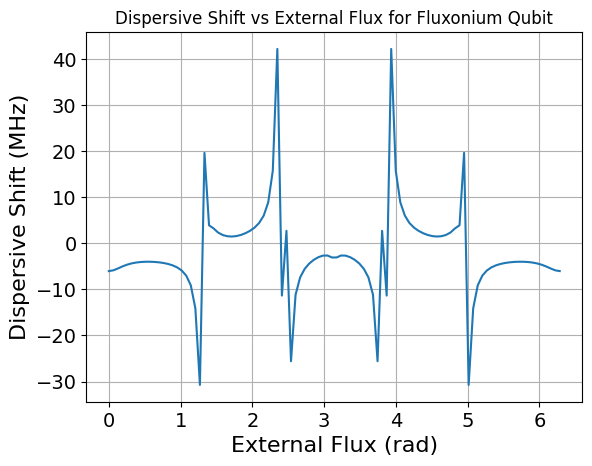

In [6]:
import matplotlib.pyplot as plt
plt.plot(phi_ext, chi_vec)
plt.xlabel('External Flux (rad)', fontsize='16')
plt.ylabel('Dispersive Shift (MHz)',fontsize='16')
plt.title('Dispersive Shift vs External Flux for Fluxonium Qubit')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.show()